# Exploratory Data Analysis: Heart Disease Prediction



## Definition: 

**Cardiovascular disease (CVD), commonly known as heart disease, refers to a range of health issues that affect the heart and blood vessels, potentially leading to conditions like heart attacks, strokes, and other related problems.**

## Problem Statement: 
**Heart diseases are a big problem all around the world, causing more than 20 million deaths each year from things like heart attacks and strokes, and more than half a billion people around the world continue to be affected by cardiovascular diseases. Even though we try to fix things like high blood pressure, bad diets, we still have trouble finding and helping the people most at risk. We could prevent about 80% of early heart attacks and strokes if we acted sooner. To fix this, we can use computers and data to predict who might get heart problems and help them early, making sure they get the right care and saving many lives.**

## First Step: Identifying the Data

**Our project focuses on analyzing a comprehensive dataset containing 1,025 patient entries, each presenting a wealth of clinical, body, and lifestyle information. We aim to extract meaningful insights that can contribute to refining risk assessment, prevention strategies, and policies, ultimately aiding in the global effort to combat the burden of cardiovascular diseases.**




* In this step, we used the opendatasets helper library to download the files of heart disease prediction dataset.

In [6]:
!pip install opendatasets --upgrade

     |████████████████████████████████| 83 kB 5.0 MB/s             
  Preparing metadata (setup.py) ... done
     |████████████████████████████████| 78 kB 14.9 MB/s            
  Created wheel for kaggle: filename=kaggle-1.5.16-py3-none-any.whl size=110701 sha256=3ca9550c128222b7219655d3c089d7aa1fa8a45715221095fae04a083e8f2b92
  Stored in directory: /home/jovyan/.cache/pip/wheels/d2/ed/a5/da3a0cfb13373d1ace41cafa4f2467d858c55c52473ba72799
Successfully built kaggle


In [8]:
import opendatasets as od
dataset = 'https://www.kaggle.com/datasets/moazeldsokyx/heart-disease?fbclid=IwAR37Zd7EotsQwG2VMTI8WVoawgM4W15Sni7Z2T2b0xwJzWauiPheleaLsNk'
od.download(dataset)

Skipping, found downloaded files in "./heart-disease" (use force=True to force download)


In [9]:
import os #import os module to work with files and directory 
os.listdir('./heart-disease')
#os.listdir() function helps us to fetch the list of files in a directory by specifying directory name as an argument.

['test.csv', 'train.csv']

In [10]:
os.listdir() #to view list of files 

['.git', '.jovianrc', 'j.ipynb', '.ipynb_checkpoints', 'heart-disease']

## Saving and uploading our notebook

**Whether we are running this Jupyter notebook online or on our computer, it's essential to save our work from time to time.** 

In [11]:
#to install jovian module
!pip install jovian --upgrade --quiet

In [12]:
import jovian


In [13]:
#assigning the name for our project notebook 
project_name = 'heart-disease-analysis'

In [14]:
#let's save our notebook
jovian.commit(project = project_name)

<IPython.core.display.Javascript object>

[jovian] Updating notebook "maismutasem38/heart-disease-analysis" on https://jovian.com
[jovian] Committed successfully! https://jovian.com/maismutasem38/heart-disease-analysis


'https://jovian.com/maismutasem38/heart-disease-analysis'

## Second Step: Data Preparation and Cleaning


### Importing the libraries and dataset:


In [15]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

### Importing the data:


In [16]:
#loding the csv data to a pandas dataframe
file_path = os.path.join('./heart-disease', 'train.csv')
data = pd.read_csv(file_path)
data


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1


## Notes about columns:


**age:** The age of the patient.

**sex:** The gender of the patient where "1" indicates Male gender, and "0" indicates Female gender.

**chest pain type(cp):** A categorical attribute indicating the type of chest pain experienced by the patient. It has four possible values:

**value 0 -->  typical angina**
   
**value 1 --> atypical angina**
   
**value 2 --> non-anginal pain**
   
**value 3 --> asymptomatic**
   

**trestbps:** resting blood pressure(measured in mm Hg upon hospital admisssion) 

**chol:** serum cholestoral in  mg/dl of the patient 

**fbs:** (fasting blood sugar>120 mg/dl)(1=true(grater than 120 mg/dl),0=false (lower than 120 mg/dl))

**restecg:** resting electrocardiographic results 
    
    * value 0:normal
    
    * value 1:having ST-T wave abnormality (T wave inversions and/or ST elevation or depression of >0.05 mV)
    
    * value 2:showing probable or definite left ventricular hypertrophy by Estes' criteria
    
    
**thalach:** maximum heart rate achieved 

**exang:** exercise induced angina(1=yes,0=no) 

**oldpeak:** ST depression induced by exercise relative to rest

**slope:** the slope of the peak exercise ST segment 

    * value 0: upsloping
    
    * value 1: flat
    
    * value 2: downsloping
    
    
**ca:** number of major vessels,Represents the number of major blood vessels colored by fluoroscopy (ranging from 0 to 3)

**thal:** A categorical attribute indicating the thalassemia type of the patient 
It has three possible values:

     * value 1:normal
     
     * value 2:fixed defect
     
     * value 3:reversible defect 


**target:** 0= absence of heart disease,1=presence of heart disease 


## Display The First 5 Rows of The Dataset

In [17]:
#what does the datafarme lock like?
data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


## Display The Last 5 Rows of The Dataset

In [12]:
data.tail()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1
1024,54,1,0,120,188,0,1,113,0,1.4,1,1,3,0


## Sample Data
We've now cleaned up and prepared the dataset for our analysis. Let's take a look at a sample of rows from the data frame

In [13]:
data.sample(5)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
585,40,1,3,140,199,0,1,178,1,1.4,2,0,3,1
269,71,0,2,110,265,1,0,130,0,0.0,2,1,2,1
291,58,1,0,128,259,0,0,130,1,3.0,1,2,3,0
410,41,0,1,105,198,0,1,168,0,0.0,2,1,2,1
499,46,0,2,142,177,0,0,160,1,1.4,0,0,2,1


## Checking for NaN values in dataset

In [14]:
#which columns are missing values and what is the extent of the missingness?
data.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

* From the above result, it's clear that there's no null values present in our data frame. If there's limited number of columns, we can also check whether a column has null value or not using info() function.

In [15]:
#what are the datatye of the columns?
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [16]:
data.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


## Check for Duplicate Data and Drop them

In [17]:
data_dup=data.duplicated().any
data_dup

<bound method NDFrame._add_numeric_operations.<locals>.any of 0       False
1       False
2       False
3       False
4       False
        ...  
1020     True
1021     True
1022     True
1023     True
1024     True
Length: 1025, dtype: bool>

In [18]:
data=data.drop_duplicates()

In [19]:
data.shape

(302, 14)

# Exploratory Data Analysis & Visualization

## Age distribution

/opt/conda/lib/python3.9/site-packages/seaborn/distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


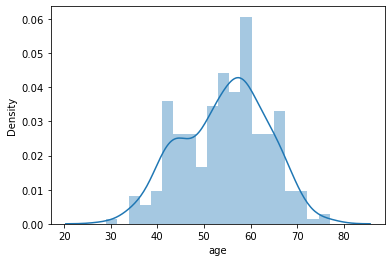

In [20]:
sns.distplot(data['age'],bins=20)
plt.show()

## gender distribution

In [21]:
data.shape

(302, 14)

In [22]:
print('Number of rows: {}'.format(data.shape[0]))
print('Number of columns: {}'.format(data.shape[1]))

Number of rows: 302
Number of columns: 14


In [23]:
print("Total number of patients in our observation is {}.".format(data.shape[0]))


Total number of patients in our observation is 302.


In [24]:
data.sex.value_counts()


1    206
0     96
Name: sex, dtype: int64

In [25]:
print("Number of Male patients in our observation is {}.".format(data.sex.value_counts()[1]))
print("Number of Female patients in our observation is {}.".format(data.sex.value_counts()[0]))

Number of Male patients in our observation is 206.
Number of Female patients in our observation is 96.


In [26]:
#to store the gender counts into a variable
gender_counts = data.sex.value_counts()

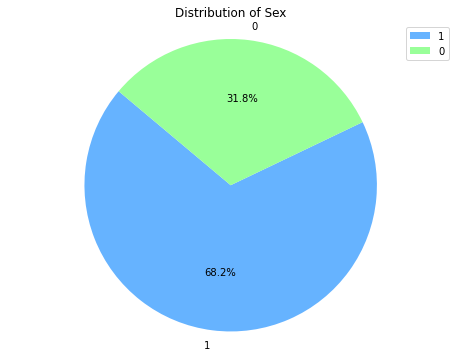

In [27]:
sex_counts = data['sex'].value_counts()
plt.figure(figsize=(8, 6))
labels = sex_counts.index
colors = ['#66b3ff', '#99ff99']
plt.pie(sex_counts, labels=labels, colors=colors, autopct='%1.1f%%', startangle=140)
plt.title("Distribution of Sex")
plt.legend(labels=labels)
plt.axis('equal') 

plt.show()







## target distribution

In [28]:
#to display column names
data.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

In [29]:
#checking the distribution of target variable
data['target'].value_counts()

1    164
0    138
Name: target, dtype: int64

* A value of 0 signifies the absence of heart disease, while a value of 1 indicates the presence of heart disease


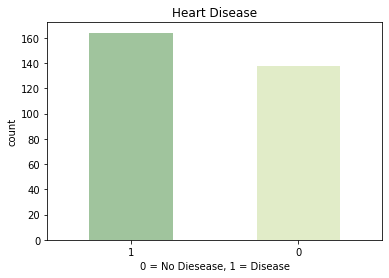

In [30]:
data.target.value_counts().plot(kind='bar', color=['#A0C49D', '#E1ECC8']);
plt.title("Heart Disease")
plt.xlabel("0 = No Diesease, 1 = Disease")
plt.ylabel("count")
plt.xticks(rotation=0);

## Find gender distribution according to the target variable

In [31]:
data.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

In [32]:
# compare target column with sex coilumn
pd.crosstab(data.target, data.sex)

sex,0,1
target,,
0,24,114
1,72,92


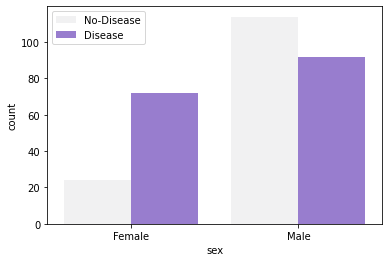

In [33]:
sns.countplot(x='sex',hue='target',data=data, color ='mediumpurple')
plt.xticks([0,1],['Female','Male'])
plt.legend(labels=['No-Disease','Disease'])
plt.show()

# Check chest pain (cp) type


* value 0: typical angina

* value 1: atypical angina

* value 2: non-anginal pain

* value 3: asymptomatic


/opt/conda/lib/python3.9/site-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


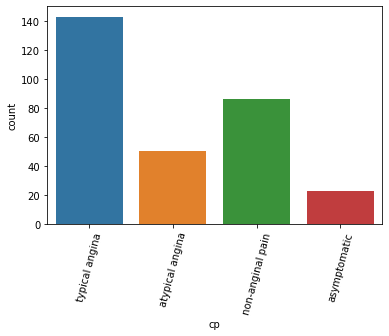

In [34]:
sns.countplot(data['cp'])
plt.xticks([0,1,2,3],['typical angina','atypical angina','non-anginal pain','asymptomatic'])
plt.xticks(rotation=75)
plt.show()

## Show the chest pain distribution as per target variable

In [35]:
data.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

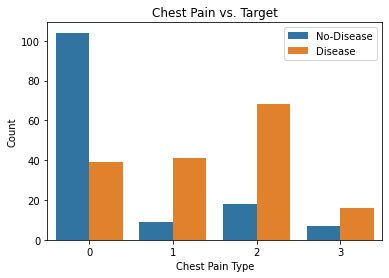

In [36]:
sns.countplot(x='cp', hue='target', data=data)
plt.title("Chest Pain vs. Target")
plt.xlabel("Chest Pain Type")
plt.ylabel("Count")
plt.legend(labels=['No-Disease', 'Disease'])

plt.show()

## Show fasting blood sugar distribution according to target variable

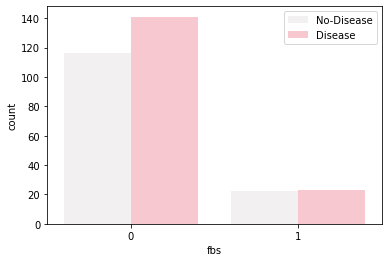

In [37]:
sns.countplot(x='fbs',hue='target',data=data, color ='pink')
plt.legend(labels=['No-Disease','Disease'])
plt.show()


/opt/conda/lib/python3.9/site-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


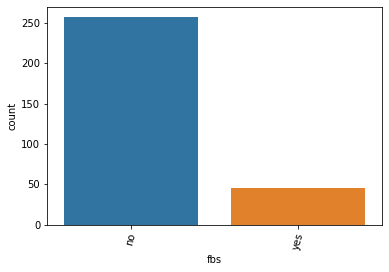

In [38]:
sns.countplot(data['fbs'])
plt.xticks([0,1],['no','yes'])
plt.xticks(rotation=75)
plt.show()

## Check resting blood pressure distribution

In [39]:
data.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

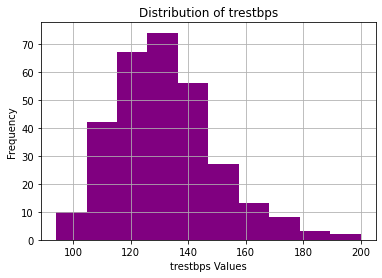

In [40]:
data['trestbps'].hist(color='purple') 
plt.title("Distribution of trestbps")
plt.xlabel("trestbps Values")
plt.ylabel("Frequency")
plt.show()

## Compare resting blood pressure as per sex

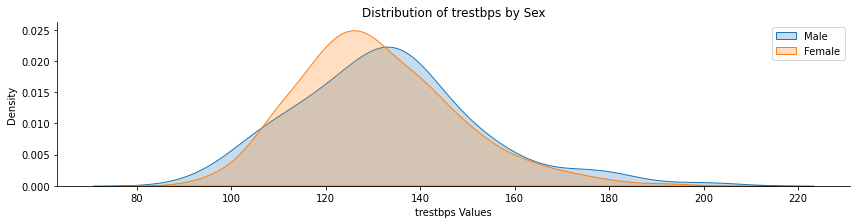

In [40]:
a = sns.FacetGrid(data, hue='sex', aspect=4)
a.map(sns.kdeplot, 'trestbps', shade=True, cmap='Blues')
plt.legend(labels=['Male', 'Female'])
plt.title("Distribution of trestbps by Sex")
plt.xlabel("trestbps Values")
plt.ylabel("Density")
plt.show()

## Compare resting blood pressure with target

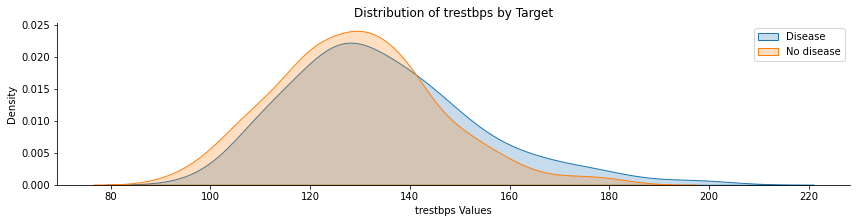

In [41]:
a = sns.FacetGrid(data, hue='target', aspect=4)
a.map(sns.kdeplot, 'trestbps', shade=True, cmap='coolwarm') 
plt.legend(labels=['Disease', 'No disease'])
plt.title("Distribution of trestbps by Target")
plt.xlabel("trestbps Values")
plt.ylabel("Density")
plt.show()

## Show distribution of serum cholesterol

In [85]:
data.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

 ## cholesterol distribution 

<AxesSubplot:>

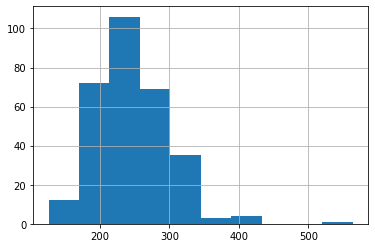

In [102]:
data['chol'].hist()

## Compare serum cholesterol as per sex

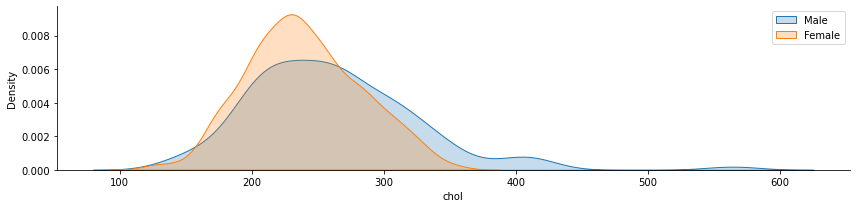

In [42]:
a=sns.FacetGrid(data,hue='sex',aspect=4)
a.map(sns.kdeplot, 'chol', shade=True)
plt.legend(labels=['Male','Female'])
plt.show()

## Compare serum cholesterol with target

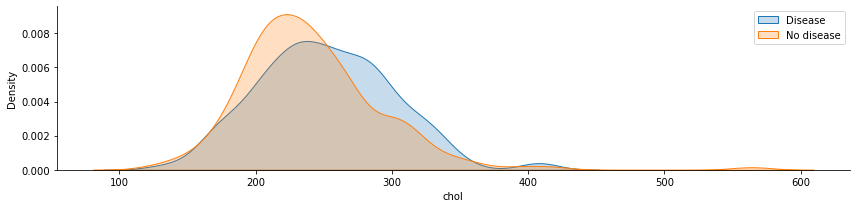

In [40]:
a=sns.FacetGrid(data,hue='target',aspect=4)
a.map(sns.kdeplot, 'chol', shade=True)
plt.legend(labels=['Disease','No disease'])
plt.show()



## Maximum Heart Rate distribution

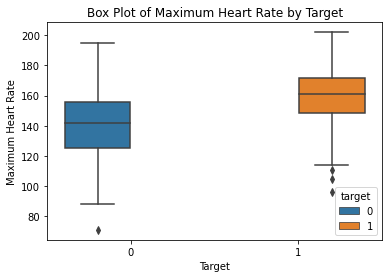

In [42]:
sns.boxplot(data=data, x='target', y='thalach', hue='target')
plt.title('Box Plot of Maximum Heart Rate by Target')
plt.xlabel('Target')
plt.ylabel('Maximum Heart Rate')
plt.show()

## Resting electrocardiographic distribution

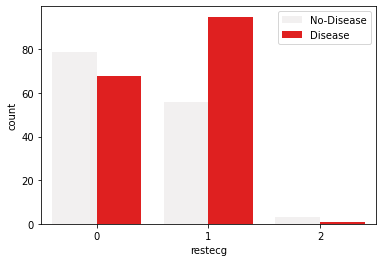

In [52]:
sns.countplot(x='restecg',hue='target',data=data, color ='red')
plt.legend(labels=['No-Disease','Disease'])
plt.show()


## Exploring the Heart disease patients based on ST Slope


In [53]:
dt = pd.DataFrame(data)
plot_criteria = ['slope', 'target']
cm = sns.light_palette('red', as_cmap=True)
crosstab_percent = (round(pd.crosstab(dt[plot_criteria[0]], dt[plot_criteria[1]], normalize='columns') * 100, 2))
styled_table = crosstab_percent.style.background_gradient(cmap=cm)
styled_table

target,0,1
slope,,
0,8.700000,5.490000
1,65.940000,29.880000
2,25.360000,64.630000


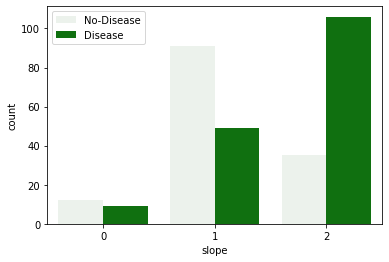

In [54]:
sns.countplot(x='slope',hue='target',data=data, color ='green')
plt.legend(labels=['No-Disease','Disease'])
plt.show()

* 0:upsloping

* 1:flat/horizontal

* 2:dowensloping

* The ST segment/heart rate slope(ST/HR slope),has been proposed as a more accurate ECG criterion for diagnosing significant coronaary artery disease (CAD) in most of the research papers.

## Unique values in dataset(without repetition)

In [60]:
dict = {}
for i in list(data.columns):
    dict[i] = data[i].value_counts().shape[0]

pd.DataFrame(dict,index=["unique count"]).transpose()

,unique count
age,41
sex,2
cp,4
trestbps,49
chol,152
fbs,2
restecg,3
thalach,91
exang,2
oldpeak,40


In [61]:
data.fbs.unique()

array([0, 1])

In [62]:
data.ca.unique()

array([2, 0, 1, 3, 4])

In [63]:
data.thal.unique()

array([3, 2, 1, 0])

In [64]:
data.target.unique()

array([0, 1])

In [65]:
data.thalach.unique()

array([168, 155, 125, 161, 106, 122, 140, 145, 144, 116, 136, 192, 156,
       142, 109, 162, 165, 148, 172, 173, 146, 179, 152, 117, 115, 112,
       163, 147, 182, 105, 150, 151, 169, 166, 178, 132, 160, 123, 139,
       111, 180, 164, 202, 157, 159, 170, 138, 175, 158, 126, 143, 141,
       167,  95, 190, 118, 103, 181, 108, 177, 134, 120, 171, 149, 154,
       153,  88, 174, 114, 195, 133,  96, 124, 131, 185, 194, 128, 127,
       186, 184, 188, 130,  71, 137,  99, 121, 187,  97,  90, 129, 113])

In [66]:
data.exang.unique()

array([0, 1])

In [67]:
data.oldpeak.unique()

array([1. , 3.1, 2.6, 0. , 1.9, 4.4, 0.8, 3.2, 1.6, 3. , 0.7, 4.2, 1.5,
       2.2, 1.1, 0.3, 0.4, 0.6, 3.4, 2.8, 1.2, 2.9, 3.6, 1.4, 0.2, 2. ,
       5.6, 0.9, 1.8, 6.2, 4. , 2.5, 0.5, 0.1, 2.1, 2.4, 3.8, 2.3, 1.3,
       3.5])

In [68]:
data.slope.unique()

array([2, 0, 1])

In [69]:
data.restecg.unique()

array([1, 0, 2])

In [70]:
data.age.unique()

array([52, 53, 70, 61, 62, 58, 55, 46, 54, 71, 43, 34, 51, 50, 60, 67, 45,
       63, 42, 44, 56, 57, 59, 64, 65, 41, 66, 38, 49, 48, 29, 37, 47, 68,
       76, 40, 39, 77, 69, 35, 74])

In [71]:
data.cp.unique()

array([0, 1, 2, 3])

In [59]:
data.trestbps.unique()

array([125, 140, 145, 148, 138, 100, 114, 160, 120, 122, 112, 132, 118,
       128, 124, 106, 104, 135, 130, 136, 180, 129, 150, 178, 146, 117,
       152, 154, 170, 134, 174, 144, 108, 123, 110, 142, 126, 192, 115,
        94, 200, 165, 102, 105, 155, 172, 164, 156, 101])

In [60]:
data.sex.unique()

array([1, 0])

In [72]:
data.chol.unique()

array([212, 203, 174, 294, 248, 318, 289, 249, 286, 149, 341, 210, 298,
       204, 308, 266, 244, 211, 185, 223, 208, 252, 209, 307, 233, 319,
       256, 327, 169, 131, 269, 196, 231, 213, 271, 263, 229, 360, 258,
       330, 342, 226, 228, 278, 230, 283, 241, 175, 188, 217, 193, 245,
       232, 299, 288, 197, 315, 215, 164, 326, 207, 177, 257, 255, 187,
       201, 220, 268, 267, 236, 303, 282, 126, 309, 186, 275, 281, 206,
       335, 218, 254, 295, 417, 260, 240, 302, 192, 225, 325, 235, 274,
       234, 182, 167, 172, 321, 300, 199, 564, 157, 304, 222, 184, 354,
       160, 247, 239, 246, 409, 293, 180, 250, 221, 200, 227, 243, 311,
       261, 242, 205, 306, 219, 353, 198, 394, 183, 237, 224, 265, 313,
       340, 259, 270, 216, 264, 276, 322, 214, 273, 253, 176, 284, 305,
       168, 407, 290, 277, 262, 195, 166, 178, 141])

# Asking and answering questions about data:


 ## Q: Which age group has the highest risk of disease?why?

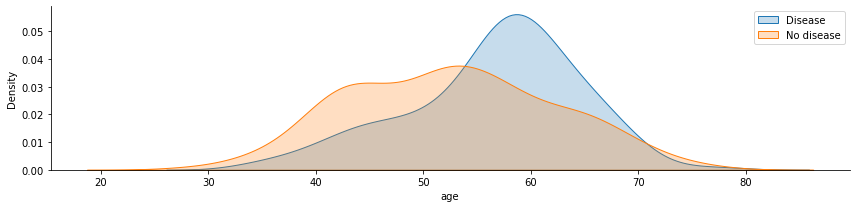

In [73]:
a=sns.FacetGrid(data,hue='target',aspect=4)
a.map(sns.kdeplot, 'age', shade=True)
plt.legend(labels=['Disease','No disease'])
plt.show()

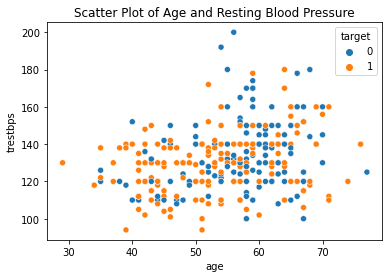

In [74]:
# Scatter plot of age and trestbps
sns.scatterplot(data=data, x='age', y='trestbps', hue='target')
plt.title('Scatter Plot of Age and Resting Blood Pressure')
plt.show()

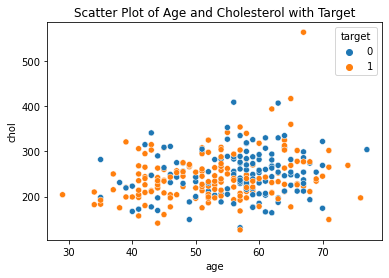

In [75]:
# Scatter plot of age and chol
sns.scatterplot(data=data, x='age', y='chol', hue='target')
plt.title('Scatter Plot of Age and Cholesterol with Target')
plt.show()

## Q: What type of thalassemia most have heart disease?

In [46]:
#Number of Patients with thal
data.thal.value_counts()


reversible defect    544
normal               417
fixed defect          64
Name: thal, dtype: int64

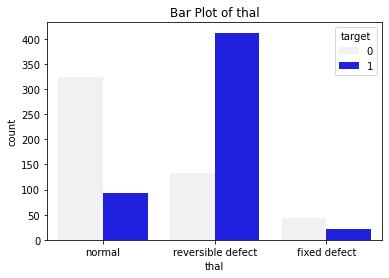

In [95]:
sns.countplot(data=data, x='thal', hue='target',color='blue')
plt.title('Bar Plot of thal')
plt.show()

## Q: Does the meaning of chest pain from exercise indicate the presence of heart disease?

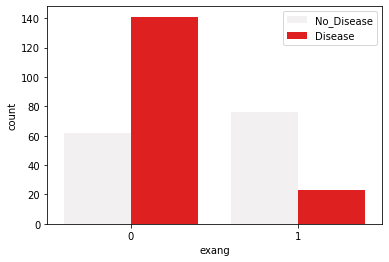

In [76]:
sns.countplot(x='exang',hue='target',data=data, color ='red')
plt.legend(labels=['No_Disease','Disease'])
plt.show()

##### we see a negative correlation between exercise induced angina (exang) & our predictor. This makes sense because when you excercise, your heart requires more blood, but narrowed arteries slow down blood flow.

## Q:How many patients have an abnormal level of sugar according to this study?how many of them have heart disease?¶

In [81]:
data.fbs.value_counts()


0    257
1     45
Name: fbs, dtype: int64

* 1: grater than 120 mg/ml so yes

* 0: lower than 120 mg/ml so no

In [83]:
abnormal_sugar_count = len(data[data['fbs'] == 1])
print("Number of patients with abnormal sugar level:", abnormal_sugar_count)


Number of patients with abnormal sugar level: 45


In [84]:
dt = pd.DataFrame(data)
plot_criteria = ['fbs', 'target']
cm = sns.light_palette('red', as_cmap=True)
crosstab_percent = (round(pd.crosstab(dt[plot_criteria[0]], dt[plot_criteria[1]], normalize='columns') * 100, 2))
styled_table = crosstab_percent.style.background_gradient(cmap=cm)
styled_table

target,0,1
fbs,,
0,84.060000,85.980000
1,15.940000,14.020000


## Q:How many patients have an abnormal level of Cholesterol? how many of them have heart disease?

In [79]:
abnormal_Cholesterol_count = len(data[data['chol'] >= 200])
print(abnormal_Cholesterol_count)


253


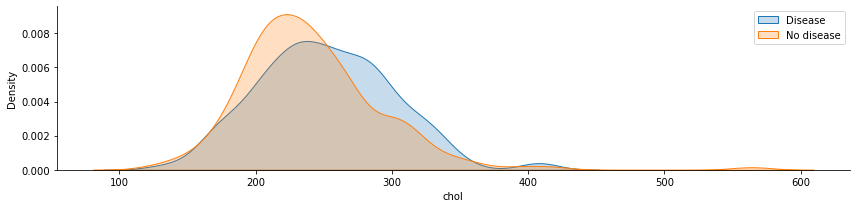

In [18]:
a=sns.FacetGrid(data,hue='target',aspect=4)
a.map(sns.kdeplot, 'chol', shade=True)
plt.legend(labels=['Disease','No disease'])
plt.show()

## Q:What is the maximum heart rate achieved has a greater chance of developing heart disease among  sex?

In [64]:
mean_max_heart_rate_by_sex = data.groupby('sex')['thalach'].mean()
print("Mean Maximum Heart Rate by Sex:")
print(mean_max_heart_rate_by_sex)
sex_with_higher_mean_hr = mean_max_heart_rate_by_sex.idxmax()
print("\nSex with the Greater Mean Maximum Heart Rate:", sex_with_higher_mean_hr)


Mean Maximum Heart Rate by Sex:
sex
0    150.830128
1    148.363254
Name: thalach, dtype: float64

Sex with the Greater Mean Maximum Heart Rate: 0


* 0: is Female

* 1: is Male